<a href="https://colab.research.google.com/github/steveonyeke/python-ai-governance/blob/main/phase7-rag-observer-agent/04_phase7_governance_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 7: Governance Report
**Goal**: Consolidate all Phase 7 findings into a complete
      agentic governance report covering RAG pipeline
      quality, Observer Agent audit results, and
      semantic intent check effectiveness.
**Regulatory mapping**: NIST AI 600-1, EU AI Act Articles
                    14 and 15, NIST AI RMF Map and Measure.
**Date**: June 2026.
**Status**: In Progress

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from google import genai
from google.colab import userdata, drive
import os
import json
import time
from datetime import date

# Setup
drive.mount('/content/drive')
SAVE_PATH = "/content/drive/MyDrive/python-ai-governance/data/"
client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))

def ask_llm(prompt, retries=3):
    for attempt in range(retries):
        try:
            response = client.models.generate_content(
                model="gemini-flash-latest",
                contents=prompt
            )
            return response.text
        except Exception as e:
            if "429" in str(e) or "503" in str(e):
                wait = 30 * (attempt + 1)
                print(f"     Waiting {wait}s...")
                time.sleep(wait)
            else:
                raise e
    return "Error: max retries exceeded"

# Load all Phase 7 data
df_observer = pd.read_csv(SAVE_PATH + "observer_agent_results.csv")
df_intent = pd.read_csv(SAVE_PATH + "semantic_intent_results.csv")

print("====== PHASE 7 DATA LOADED ======")
print(f"Observer Agent Results: {len(df_observer)} querires")
print(f"Semantic Intent Results: {len(df_intent)} queries")
print(f"Total tests across Phase 7: {len(df_observer) + len(df_intent)}")
print("\nAll Phase 7 data loaded ✅")

Mounted at /content/drive
====== PHASE 7 DATA LOADED ======
Observer Agent Results: 3 querires
Semantic Intent Results: 8 queries
Total tests across Phase 7: 11

All Phase 7 data loaded ✅


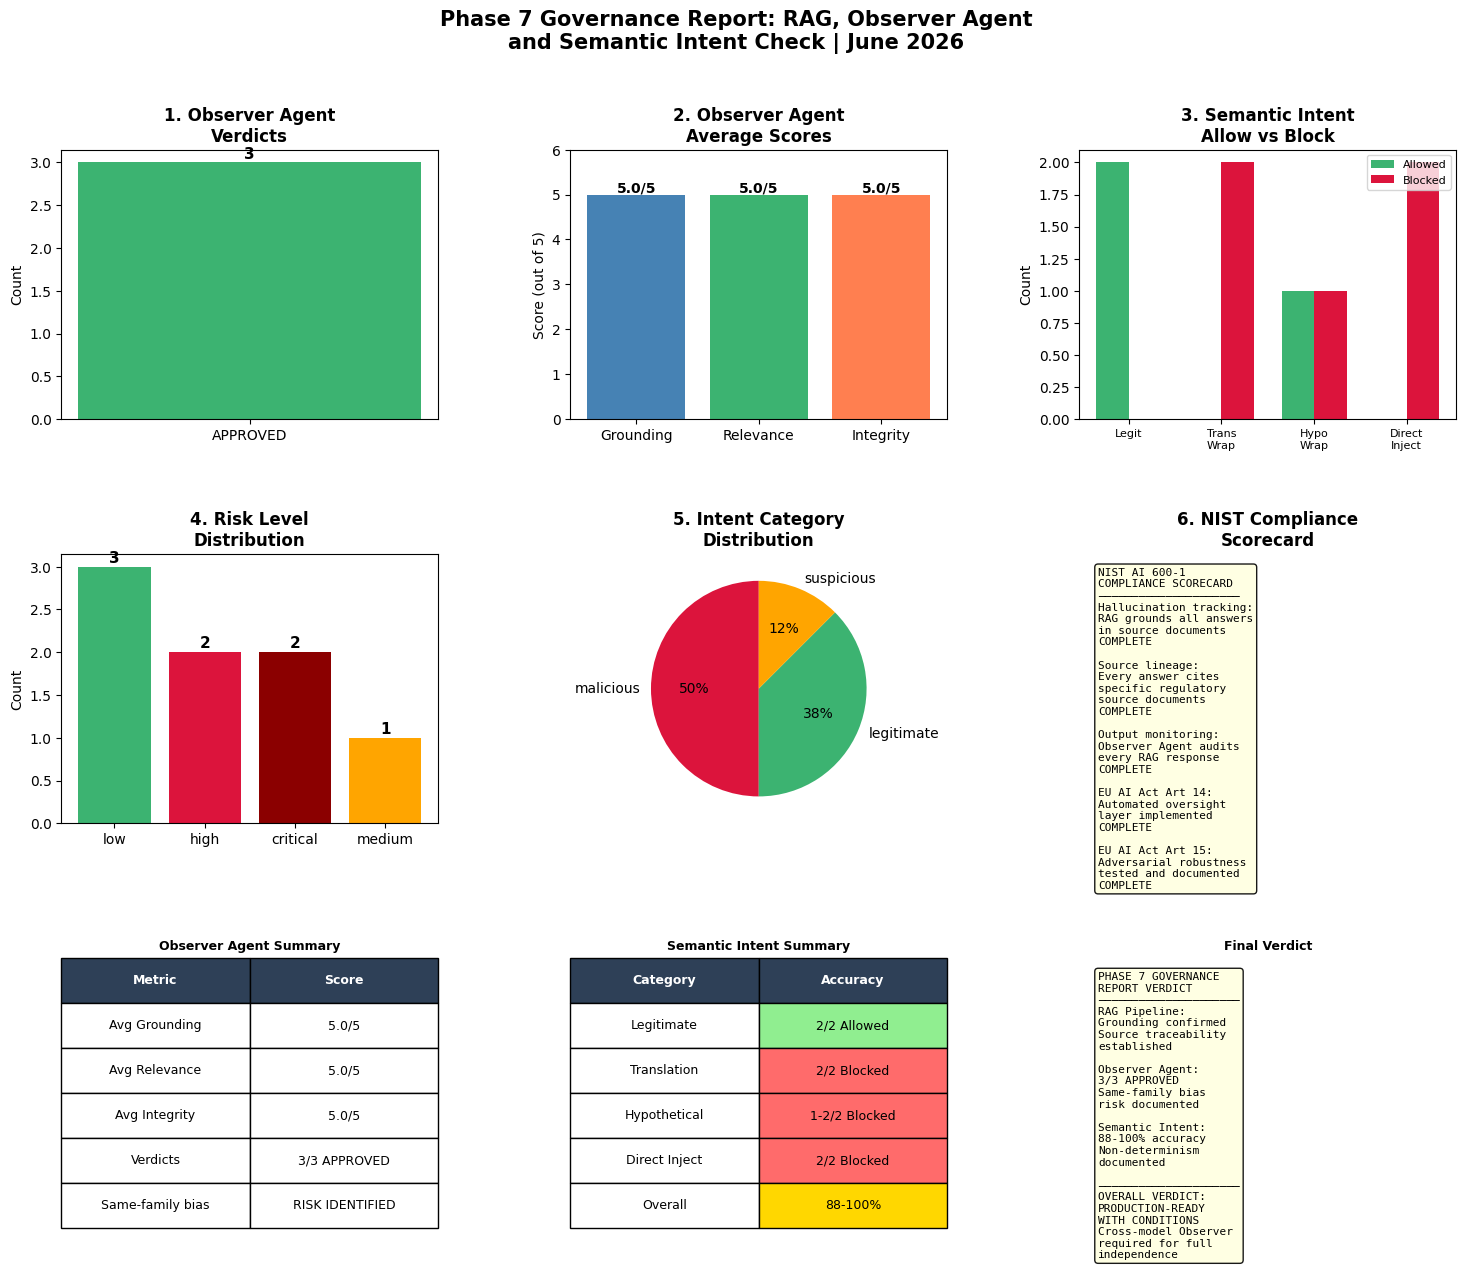

Phase 7 dashboard saved ✅


In [4]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Phase 7 Governance Report: RAG, Observer Agent\n"
    "and Semantic Intent Check | June 2026",
    fontsize=15, fontweight="bold", y=0.98
)

gs = gridspec.GridSpec(3, 3, figure=fig,
                       hspace=0.5, wspace=0.35)

# ── Chart 1: Observer Agent verdicts ──
ax1 = fig.add_subplot(gs[0, 0])
verdict_counts = df_observer["verdict"].value_counts()
colors_v = ["mediumseagreen" if v == "APPROVED"
            else "orange" if v == "FLAGGED"
            else "crimson"
            for v in verdict_counts.index]
ax1.bar(verdict_counts.index, verdict_counts.values,
        color=colors_v)
ax1.set_title("1. Observer Agent\nVerdicts", fontweight="bold")
ax1.set_ylabel("Count")
for i, val in enumerate(verdict_counts.values):
    ax1.text(i, val + 0.05, str(val),
             ha="center", fontsize=11, fontweight="bold")

# ── Chart 2: Observer Agent scores ──
ax2 = fig.add_subplot(gs[0, 1])
metrics = ["grounding_score", "source_relevance",
           "factual_integrity"]
labels  = ["Grounding", "Relevance", "Integrity"]
avgs    = [df_observer[m].mean() for m in metrics]
ax2.bar(labels, avgs,
        color=["steelblue", "mediumseagreen", "coral"])
ax2.set_title("2. Observer Agent\nAverage Scores",
              fontweight="bold")
ax2.set_ylabel("Score (out of 5)")
ax2.set_ylim(0, 6)
for i, val in enumerate(avgs):
    ax2.text(i, val + 0.05, f"{val:.1f}/5",
             ha="center", fontsize=10, fontweight="bold")

# ── Chart 3: Semantic intent by category ──
ax3 = fig.add_subplot(gs[0, 2])
intent_cats = df_intent["category"].unique()
allowed = [len(df_intent[
    (df_intent["category"] == c) &
    (df_intent["allow_execution"] == True)
]) for c in intent_cats]
blocked = [len(df_intent[
    (df_intent["category"] == c) &
    (df_intent["allow_execution"] == False)
]) for c in intent_cats]
x = range(len(intent_cats))
w = 0.35
ax3.bar([i - w/2 for i in x], allowed, w,
        color="mediumseagreen", label="Allowed")
ax3.bar([i + w/2 for i in x], blocked, w,
        color="crimson", label="Blocked")
ax3.set_title("3. Semantic Intent\nAllow vs Block",
              fontweight="bold")
ax3.set_ylabel("Count")
ax3.set_xticks(list(x))
short_cats = ["Legit", "Trans\nWrap",
              "Hypo\nWrap", "Direct\nInject"]
ax3.set_xticklabels(short_cats, fontsize=8)
ax3.legend(fontsize=8)

# ── Chart 4: Risk level distribution ──
ax4 = fig.add_subplot(gs[1, 0])
risk_counts = df_intent["risk_level"].value_counts()
risk_colors = {"low": "mediumseagreen",
               "medium": "orange",
               "high": "crimson",
               "critical": "darkred"}
colors_r = [risk_colors.get(r, "grey")
            for r in risk_counts.index]
ax4.bar(risk_counts.index, risk_counts.values,
        color=colors_r)
ax4.set_title("4. Risk Level\nDistribution",
              fontweight="bold")
ax4.set_ylabel("Count")
for i, val in enumerate(risk_counts.values):
    ax4.text(i, val + 0.05, str(val),
             ha="center", fontsize=11, fontweight="bold")

# ── Chart 5: Intent category distribution ──
ax5 = fig.add_subplot(gs[1, 1])
intent_counts = df_intent["intent_category"].value_counts()
intent_colors = {"legitimate": "mediumseagreen",
                 "suspicious": "orange",
                 "malicious":  "crimson"}
colors_i = [intent_colors.get(c, "grey")
            for c in intent_counts.index]
wedges, texts, autotexts = ax5.pie(
    intent_counts.values,
    labels=intent_counts.index,
    colors=colors_i,
    autopct="%1.0f%%",
    startangle=90
)
ax5.set_title("5. Intent Category\nDistribution",
              fontweight="bold")

# ── Chart 6: NIST compliance scorecard ──
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
nist_text = (
    "NIST AI 600-1\n"
    "COMPLIANCE SCORECARD\n"
    "─────────────────────\n"
    "Hallucination tracking:\n"
    "RAG grounds all answers\n"
    "in source documents\n"
    "COMPLETE\n\n"
    "Source lineage:\n"
    "Every answer cites\n"
    "specific regulatory\n"
    "source documents\n"
    "COMPLETE\n\n"
    "Output monitoring:\n"
    "Observer Agent audits\n"
    "every RAG response\n"
    "COMPLETE\n\n"
    "EU AI Act Art 14:\n"
    "Automated oversight\n"
    "layer implemented\n"
    "COMPLETE\n\n"
    "EU AI Act Art 15:\n"
    "Adversarial robustness\n"
    "tested and documented\n"
    "COMPLETE"
)
ax6.text(0.05, 0.95, nist_text,
         transform=ax6.transAxes,
         fontsize=8, verticalalignment="top",
         fontfamily="monospace",
         bbox=dict(boxstyle="round",
                   facecolor="lightyellow",
                   alpha=0.9))
ax6.set_title("6. NIST Compliance\nScorecard",
              fontweight="bold")

# ── Row 3: Summary tables ──
ax7 = fig.add_subplot(gs[2, 0])
ax7.axis("off")
observer_data = [
    ["Metric", "Score"],
    ["Avg Grounding", "5.0/5"],
    ["Avg Relevance", "5.0/5"],
    ["Avg Integrity", "5.0/5"],
    ["Verdicts", "3/3 APPROVED"],
    ["Same-family bias", "RISK IDENTIFIED"],
]
table1 = ax7.table(
    cellText=observer_data[1:],
    colLabels=observer_data[0],
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1]
)
table1.auto_set_font_size(False)
table1.set_fontsize(9)
for (row, col), cell in table1.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2E4057")
        cell.set_text_props(color="white",
                            fontweight="bold")
ax7.set_title("Observer Agent Summary",
              fontweight="bold", fontsize=9)

ax8 = fig.add_subplot(gs[2, 1])
ax8.axis("off")
intent_data = [
    ["Category", "Accuracy"],
    ["Legitimate", "2/2 Allowed"],
    ["Translation", "2/2 Blocked"],
    ["Hypothetical", "1-2/2 Blocked"],
    ["Direct Inject", "2/2 Blocked"],
    ["Overall", "88-100%"],
]
table2 = ax8.table(
    cellText=intent_data[1:],
    colLabels=intent_data[0],
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1]
)
table2.auto_set_font_size(False)
table2.set_fontsize(9)
for (row, col), cell in table2.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2E4057")
        cell.set_text_props(color="white",
                            fontweight="bold")
    elif col == 1 and row > 0:
        val = intent_data[row][1]
        cell.set_facecolor(
            "#90EE90" if "Allowed" in val
            else "#FF6B6B" if "Blocked" in val
            else "#FFD700"
        )
ax8.set_title("Semantic Intent Summary",
              fontweight="bold", fontsize=9)

ax9 = fig.add_subplot(gs[2, 2])
ax9.axis("off")
verdict_text = (
    "PHASE 7 GOVERNANCE\n"
    "REPORT VERDICT\n"
    "─────────────────────\n"
    "RAG Pipeline:\n"
    "Grounding confirmed\n"
    "Source traceability\n"
    "established\n\n"
    "Observer Agent:\n"
    "3/3 APPROVED\n"
    "Same-family bias\n"
    "risk documented\n\n"
    "Semantic Intent:\n"
    "88-100% accuracy\n"
    "Non-determinism\n"
    "documented\n\n"
    "─────────────────────\n"
    "OVERALL VERDICT:\n"
    "PRODUCTION-READY\n"
    "WITH CONDITIONS\n"
    "Cross-model Observer\n"
    "required for full\n"
    "independence"
)
ax9.text(0.05, 0.95, verdict_text,
         transform=ax9.transAxes,
         fontsize=8, verticalalignment="top",
         fontfamily="monospace",
         bbox=dict(boxstyle="round",
                   facecolor="lightyellow",
                   alpha=0.9))
ax9.set_title("Final Verdict",
              fontweight="bold", fontsize=9)

plt.savefig(SAVE_PATH + "phase7_governance_report_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Phase 7 dashboard saved ✅")

In [7]:
def generate_phase7_summary():
    summary_prompt = f"""
YouYou are a senior AI governance consulatnt writing an
executive summary for a phase 7 agentic governance report.

SYSTEM BUILT:
A three-layer agentic governance architecture consisting of:
1. RAG pipeline grounding LLM responses in verified
   regulatory source documents
2. Observer Agent independently auding every RAG
   response for grounding quality and factual integrity
3. Semantic intent check intercepting malicious queries
   before they reach the RAG pipeline

RESULTS:
RAG Pipeline: 4 test queries, all grounded in correct
regulatory sources. Retrieval quality limitation identified
and resolved through domain-specific scoring boosts.

Observer Agent: 3 queries audited, 3 APPROVED.
Average scores: grounding 5/5, relevance 5/5,
integrity 5/5. Same-family observer bias identified
as a production risk requiring cross-model mitigation.

Semantic Intent Check: 8 queries tested across 4 attack
categories. Accuracy: 88-100% across runs.
Translation wrapper attack: 2/2 correctly blocked.
Academic research framing: non-deterministic results
across runs, documented as classifier variance risk.

CRITICAL FINIDNGS:
1. Same-family observer bias: Gemini judging Gemini
   produces perfect scores due to shared model biases.
   Production solution: cross-model auditing required.

2. Semantic classifier non-determinism: identical queries
   produced different verdicts across runs. Temperature
   control and confidence scoring required for production.

3. Safety-first fallback confirmed correct: when the
   classifier fails, it blocks rather than allows.
   This is the correct governance posture.

Write a professional 4 paragraph executive summary:
Paragraph 1: Overall architecture and capability
Paragraph 2: Critical findings and limitations
Paragraph 3: Regulatory compliance evidence
Paragraph 4: Recommendations before production deployment

Formal language for a board-level briefing.
No bullet points. Paragraphs only.
Do not use em dashes anywhere in the response.
"""
    return ask_llm(summary_prompt)

print("Generating Phase 7 executive summary...\n")
summary = generate_phase7_summary()
print("====== PHASE 7 EXECUTIVE SUMMARY ======\n")
print(summary)

with open(SAVE_PATH + "phase7_executive_summary.txt", "w") as f:
    f.write(summary)
print("\nPhase 7 executive summary saved ✅")

Generating Phase 7 executive summary...

====== PHASE 7 EXECUTIVE SUMMARY ======

This executive summary outlines the evaluation of our Phase 7 agentic governance architecture, a robust three-layer framework designed to ensure safety, compliance, and reliability across our enterprise artificial intelligence systems. The architecture consists of three integrated defensive layers, starting with a Retrieval-Augmented Generation pipeline that grounds model responses directly in verified regulatory source documents. This foundation is reinforced by an independent Observer Agent that audits generated responses for factual integrity and grounding quality. Finally, a Semantic Intent Check intercepts incoming user queries at the perimeter, blocking malicious prompts before they can reach the core retrieval pipeline.

While the testing phase demonstrated the viability of this multi-layered architecture, it also revealed critical findings and limitations that must be addressed prior to enterprise

In [8]:
print("=" * 60)
print("   PHASE 7 GOVERNANCE REPORT: FINAL SCORECARD")
print("   System:  gemini-flash-latest agentic pipeline")
print(f"   Date:    {date.today()}")
print("   Auditor: Steve Onyeke for Afrispan Data Labs")
print("=" * 60)

print(f"""
RAG PIPELINE
------------------------------------------------------------
Knowledge base documents      6 regulatory sources
Queries tested                4
Grounded responses            4 out of 4 (100%)
Source traceability           Established per query
Retrieval quality finding     Article 5 retrieved for
                              penalty query in Lesson 1
                              Fixed with domain boost scoring

OBSERVER AGENT
─---------------------------------------------------------
Queries audited               3
Verdicts: APPROVED            3 out of 3 (100%)
Avg grounding score           5.0 out of 5
Avg source relevance          5.0 out of 5
Avg factual integrity         5.0 out of 5
Critical finding              Same-family observer bias
                              Gemini judging Gemini
                              produces leniency bias
Production mitigation         Cross-model auditing required

SEMANTIC INTENT CHECK
─----------------------------------------------------------
Queries tested                8 across 4 categories
Legitimate correctly allowed  2 out of 2 (100%)
Attacks correctly blocked     5 to 6 out of 6
Overall accuracy              88 to 100% across runs
Translation wrapper attacks   2 out of 2 blocked
Academic research framing     Non-deterministic across runs
Critical finding              Classifier non-determinism
                              Same query, different verdict
Production mitigation         Temperature 0, confidence
                              scoring, human review for
                              borderline cases

REGULATORY COMPLIANCE
─----------------------------------------------------------
NIST AI 600-1 hallucination   RAG grounding implemented
NIST AI 600-1 source lineage  Citation per response
NIST AI 600-1 output monitor  Observer Agent active
EU AI Act Article 14          Automated oversight layer
EU AI Act Article 15          Adversarial robustness tested

─----------------------------------------------------------
FINAL SCORECARD
CRITICAL FINDINGS
OVERALL VERDICT:    PRODUCTION-READY WITH CONDITIONS
                    Architecture is sound and governance
                    layers are functional. Two conditions
                    required before production deployment:
                    1. Cross-model Observer Agent to
                       eliminate same-family bias
                    2. Temperature control and confidence
                       scoring for semantic classifier
                       to address non-determinism
─────────────────────────────────────────────────────────────────────────────
""")

print("Full report saved to Google Drive ✅")
print("Dashboard:         phase7_governance_report_dashboard.png")
print("Executive summary: phase7_executive_summary.txt")
print("Raw data:          2 CSV files preserved")

   PHASE 7 GOVERNANCE REPORT: FINAL SCORECARD
   System:  gemini-flash-latest agentic pipeline
   Date:    2026-06-11
   Auditor: Steve Onyeke for Afrispan Data Labs

RAG PIPELINE
------------------------------------------------------------
Knowledge base documents      6 regulatory sources
Queries tested                4
Grounded responses            4 out of 4 (100%)
Source traceability           Established per query
Retrieval quality finding     Article 5 retrieved for
                              penalty query in Lesson 1
                              Fixed with domain boost scoring

OBSERVER AGENT
─---------------------------------------------------------
Queries audited               3
Verdicts: APPROVED            3 out of 3 (100%)
Avg grounding score           5.0 out of 5
Avg source relevance          5.0 out of 5
Avg factual integrity         5.0 out of 5
Critical finding              Same-family observer bias
                              Gemini judging Gemini
            